## Random Forest (Classification)

The core idea is simple: instead of relying on one "decision tree," Random Forest builds a "forest" of many trees. The final result is determined by the majority vote of all trees.

In addition to randomizing data, Random Forest also randomizes features. at each split in a tree, the algorithm considers only a random subset of features (e.g., only "Amount" and "Time", ignoring "Location").

Training Phase:

+ The algorithm builds 
N decision trees (e.g., 100 trees).
Each tree learns from a random slice of the data.

Prediction Phase:

+ When a new data point arrives, it is passed through every tree.
Each tree gives a vote (e.g., Tree 1 says "Normal", Tree 2 says "Fraud").
The final output is the option with the most votes.



1 Setup libraries

In [1]:
import pandas as pd
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

2 Load Data

Reads the labeled dataset (data_labeled.json) — the one already tagged with is_fraud by the Isolation Forest — and previews the first few rows.

In [2]:

df = pd.read_json("../data/data_2/data_labeled.json")
df.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Gender,Location,Account balance,Transaction Count,Working Status,Salary (per month),Age,Balance_to_Salary_Ratio,Transaction_to_Balance_Ratio,Hour,DayOfWeek,is_fraud,anomaly_score
0,TXN_300001,ACC_06255,REC_3912,0.436816,2025-11-17 07:34:00,3,1,4,2,1,0.252505,10,2,0.177778,0.414634,0.097504,0.003572,7,0,0,-0.539102
1,TXN_300002,ACC_04472,REC_7262,0.168972,2025-08-13 07:31:00,1,1,3,1,6,0.088176,3,5,0.355556,0.170732,0.021225,0.003929,7,2,0,-0.517723
2,TXN_300003,ACC_00398,REC_3277,0.309114,2025-01-24 15:14:00,1,1,3,0,0,0.326653,4,5,0.266667,0.463415,0.096282,0.001959,15,4,0,-0.482311
3,TXN_300004,ACC_06061,REC_4510,0.923370,2025-08-16 20:45:00,6,2,2,2,6,0.462926,2,2,0.933333,0.926829,0.049164,0.004124,20,5,0,-0.514468
4,TXN_300005,ACC_09143,REC_4206,0.368501,2025-05-06 21:27:00,0,2,2,0,5,0.749499,2,3,0.377778,0.048780,0.170282,0.001018,21,1,0,-0.502332


3 Pick features

Selects all the input columns the model will learn from (amounts, balances, time, demographics, etc.) as X, and sets is_fraud as the target y it's trying to predict.


In [3]:

feature_columns = [
    'Transaction amount', 'Account balance', 'Salary (per month)',
    'Hour', 'DayOfWeek', 'Age', 'Is_Weekend', 'Is_Night',
    'Balance_to_Salary_Ratio', 'Transaction_to_Balance_Ratio',
    'Transaction Detail', 'Geological', 'Device Use', 
    'Location', 'Working Status', 'Gender', 'Transaction Count'
]

available = [col for col in feature_columns if col in df.columns]
X = df[available].copy()
y = df['is_fraud']

4 Train model

Splits data into 80% for training and 20% for testing, then trains the Random Forest with 100 trees. Unlike Isolation Forest, this model learns directly from the fraud labels.



In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


save model


In [5]:
#change to your path 
joblib.dump(model, '../models/isolation_forest.pkl')

['../models/isolation_forest.pkl']

5 Evaluate

Tests the model on the unseen 20% test set and prints the overall accuracy plus a full report showing precision, recall, and F1-score for both Normal and Fraud classes.


In [6]:
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions, target_names=['Normal', 'Fraud']))


Accuracy: 91.50%
              precision    recall  f1-score   support

      Normal       0.92      0.99      0.95      4240
       Fraud       0.87      0.52      0.65       760

    accuracy                           0.92      5000
   macro avg       0.89      0.75      0.80      5000
weighted avg       0.91      0.92      0.91      5000



7 Show importances impact to Detection 

Shows which features had the biggest impact on the model's decisions — helps you understand what the model is actually paying attention to (e.g., Transaction Amount vs. Account Balance).



In [7]:
importance_df = pd.DataFrame({
    'Features': X.columns,  
    'Importances': model.feature_importances_
}).sort_values('Importances', ascending=False)

print(importance_df.head(5).to_string(index=False))


                    Features  Importances
     Balance_to_Salary_Ratio     0.159353
Transaction_to_Balance_Ratio     0.156206
             Account balance     0.118632
          Salary (per month)     0.098165
          Transaction amount     0.081661


8 Visualization


8.1 Feature Importance Bar Chart 

A horizontal bar chart ranking every feature by how much it influenced fraud detection

Text(0.5, 0, 'Importance Score')

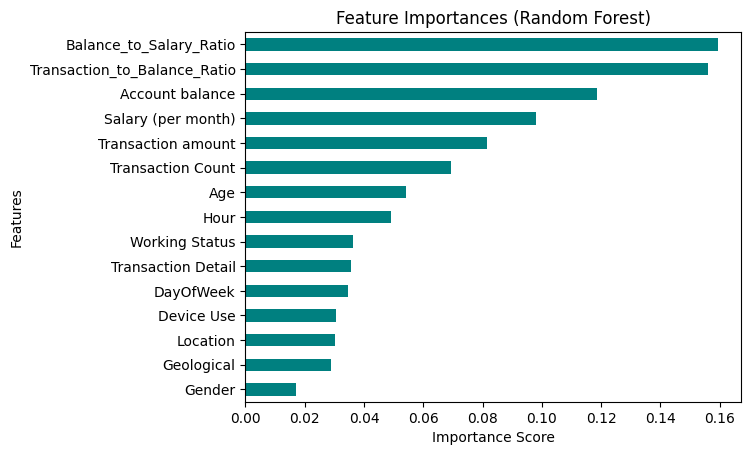

In [8]:
import matplotlib.pyplot as plt

importance_df.sort_values('Importances').plot(kind='barh', x='Features', y='Importances', legend=False, color='teal')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')

5.2 Confusion Matrix

A grid showing correct and incorrect predictions — how many frauds were caught vs. missed

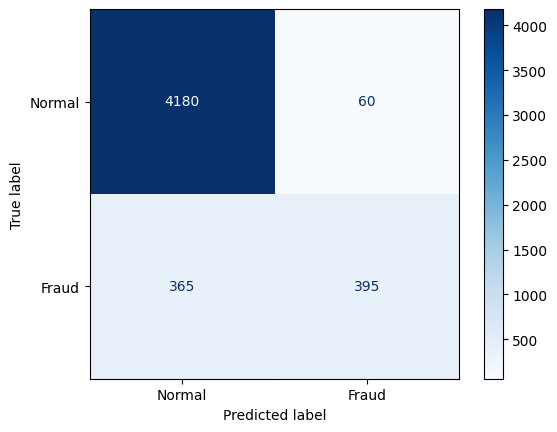

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['Normal','Fraud'], cmap='Blues')

5.3 ROC Curve

Shows the trade-off between catching real fraud and generating false alarms at different thresholds

Text(0.5, 1.0, 'ROC Curve - Random Forest')

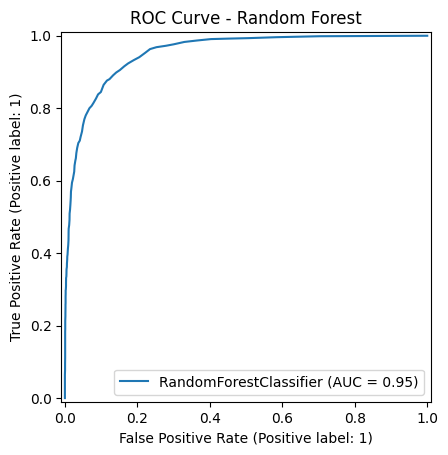

In [10]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve - Random Forest')

5.4 Precision-Recall Curve

More useful than ROC for fraud (imbalanced data) — shows the balance between precision (not crying wolf) and recall (catching all frauds)

Text(0.5, 1.0, 'Precision-Recall Curve')

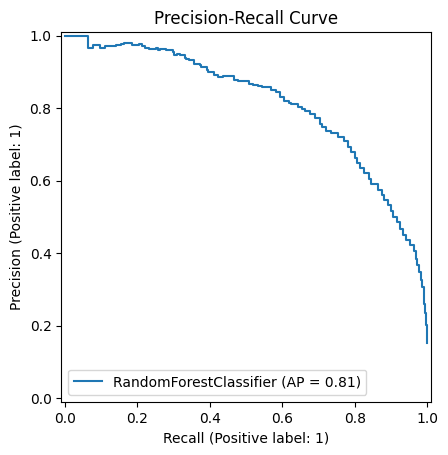

In [11]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.title('Precision-Recall Curve')

5.5 Single Tree Visualization 

Draws one of the 100 trees so you can visually trace the exact decision logic the model uses

[Text(0.5431034482758621, 0.9, 'Is_Weekend <= 0.473\ngini = 0.254\nsamples = 12681\nvalue = [17012, 2988]\nclass = Normal'),
 Text(0.27586206896551724, 0.7, 'Account balance <= 0.069\ngini = 0.216\nsamples = 12207\nvalue = [16851, 2371]\nclass = Normal'),
 Text(0.40948275862068967, 0.8, 'True  '),
 Text(0.13793103448275862, 0.5, 'Location <= 0.5\ngini = 0.487\nsamples = 847\nvalue = [551.0, 763.0]\nclass = Fraud'),
 Text(0.06896551724137931, 0.3, 'Is_Weekend <= 0.008\ngini = 0.4\nsamples = 231\nvalue = [97, 254]\nclass = Fraud'),
 Text(0.034482758620689655, 0.1, '\n  (...)  \n'),
 Text(0.10344827586206896, 0.1, '\n  (...)  \n'),
 Text(0.20689655172413793, 0.3, 'Is_Weekend <= 0.002\ngini = 0.498\nsamples = 616\nvalue = [454, 509]\nclass = Fraud'),
 Text(0.1724137931034483, 0.1, '\n  (...)  \n'),
 Text(0.2413793103448276, 0.1, '\n  (...)  \n'),
 Text(0.41379310344827586, 0.5, 'Is_Weekend <= 0.265\ngini = 0.163\nsamples = 11360\nvalue = [16300, 1608]\nclass = Normal'),
 Text(0.34482758620

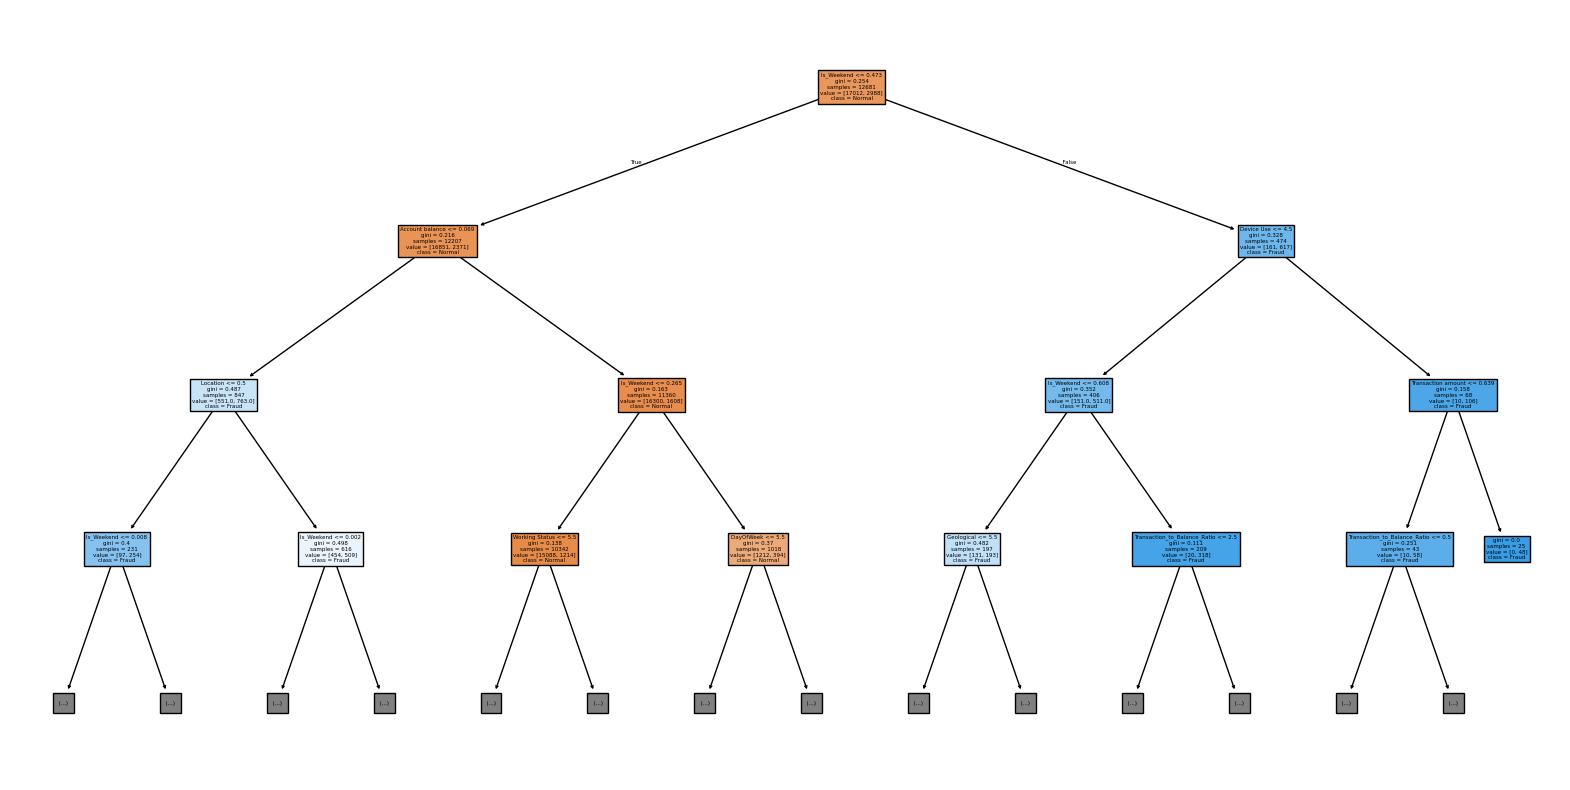

In [12]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=feature_columns, class_names=['Normal','Fraud'], max_depth=3, filled=True)